# SSH Brute-Force Detection — v3 (diverse behaviors + IP-level/time-window aggregation)

**Why v3 exists:** the v2 review found the dataset only had 9 attack patterns evaluated purely at the
*session* level, all data was synthetic, and per-class breakdowns showed several "hard" classes were
still perfectly separable (a warning v2 itself raised and never resolved), plus two real feature-engineering
bugs (`n_success` was a deterministic duplicate of `n_events - n_failed`; `attempts_per_minute` divided by
a near-zero duration for 32.5% of sessions, producing a `1,000,000` outlier).

**What v3 changes:**
- Event vocabulary expanded (`Invalid user`, `Accepted publickey`, not just Failed/Accepted password) —
  grounded in real `auth.log` format.
- 5 new attack behaviors grounded in real SSH brute-force research (NSDI'24, NDSS billion-scale study):
  `large_dictionary_scanner`, `credential_stuffing`, `persistent_multiday_attacker`,
  `coordinated_botnet_spike`, plus a new **hard negative** `legit_multi_ip_roaming`.
- **IP-level cross-session features** (session count per IP, active-day span, total events, unique
  usernames targeted per IP) — needed because `persistent_multiday_attacker` and (after realistic
  10-minute session-gap splitting) `low_and_slow` both look tiny/innocuous at the *session* level.
- **Time-window cross-IP feature** (`distinct_ips_same_target_15min`) — needed because
  `coordinated_botnet_spike` looks like an isolated small burst from any single IP's perspective; only
  counting *other* IPs hitting the same target in a trailing window reveals the coordination.
- Every feature was run through an evidence-based verification pipeline (sanity/identity check,
  correlation + VIF, mutual information, permutation importance, bootstrap stability, group ablation,
  and an OOD check) *before* being kept or dropped — see `verify_features_v3.py` and section 3 below.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_curve, average_precision_score, f1_score,
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)


## 1. Load session-level + IP-level + time-window features

Already computed by `extract_features_v3.py` from the raw event log `ssh_dataset_v3.csv` (main) and `ssh_dataset_v3_ood.csv` (held out, different seed + shifted day span, never touched below until the OOD section).

In [2]:
features = pd.read_csv("ssh_features_v3.csv", parse_dates=["session_start", "session_end"])
features_ood = pd.read_csv("ssh_features_v3_ood.csv", parse_dates=["session_start", "session_end"])
print("Main:", features.shape, " OOD:", features_ood.shape)
print("\nSessions by Attack_Type (main):")
print(features["Attack_Type"].value_counts())


Main: (3913, 31)  OOD: (3316, 31)

Sessions by Attack_Type (main):
Attack_Type
low_and_slow                    1078
legit_success                    620
legit_typo                       480
burst_bruteforce                 440
persistent_multiday_attacker     349
coordinated_botnet_spike         288
legit_multi_ip_roaming           162
password_spray                   109
shared_ip_legit                  107
ambiguous_legit                   70
focused_bruteforce                70
ambiguous_attack                  65
credential_stuffing               45
large_dictionary_scanner          30
Name: count, dtype: int64


## 2. Final feature set — evidence, not guesswork

`verify_features_v3.py` ran 7 checks against every one of the 23 raw candidate columns
(sanity/identity, correlation+VIF, mutual information, permutation importance, bootstrap stability,
group ablation, OOD check). The decisions below are traceable to that output, not assumption.

**Dropped (9), each with the specific evidence:**
| Feature | Reason |
|---|---|
| `n_events` | 100% deterministic: `n_failed + n_invalid_user + n_success == n_events` for every session |
| `n_invalid_user` (raw count) | VIF = inf; 0.94-0.998 correlated with the username/port diversity cluster below. `invalid_ratio` kept instead. |
| `username_entropy` | 0.77 correlated with `n_unique_usernames`, near-zero incremental permutation importance |
| `n_unique_ports` | 0.95-0.96 correlated with the username/invalid-user cluster; generator also assigns a fresh ephemeral port per event regardless of pattern, so its real-world validity is unverified anyway |
| `ip_unique_usernames_targeted` | 0.9996 correlated with session-level `n_unique_usernames` — most IPs in this data have exactly one session, so the IP-level version is nearly an exact duplicate |
| `mean_inter_arrival_s`, `median_inter_arrival_s`, `min_inter_arrival_s` | mutually 0.95-0.998 correlated with each other and with `duration_seconds`; `std_inter_arrival_s` kept as the one "irregularity" representative, `duration_seconds` kept as the one "total spread" representative |

**Kept (15):** `fail_ratio`, `n_failed`, `n_success`, `invalid_ratio`, `publickey_ratio`, `n_unique_usernames`,
`targets_default_username`, `ends_after_success`, `duration_seconds`, `std_inter_arrival_s`,
`attempts_per_minute`, `ip_session_count`, `ip_active_span_days`, `ip_sessions_per_day`, `ip_total_events`,
`distinct_ips_same_target_15min`.

**One deliberate exception:** `distinct_ips_same_target_15min` has the *smallest* group-ablation impact on
binary PR-AUC (-0.0006) of anything kept — group ablation measures the binary attack/legit decision, and a
`coordinated_botnet_spike` session already looks like an attack from `fail_ratio`/`ends_after_success`
alone. But per-class inspection (below) shows this feature is a *near-perfect single-feature classifier for
that one attack type specifically* (median 26 distinct IPs vs. 0-2 for every other type). It's kept because
the stated goal is detecting **which** diverse behavior occurred, not just attack-vs-not — a binary metric
systematically undervalues a feature that does this job.


### 2.0 Evidence: sample of extracted features, correlation, VIF, mutual information

Before the kept/dropped decision below, this is what it's actually based on: a look at real extracted
feature values, the full correlation matrix and VIF across all 24 raw candidates, and each feature's
univariate mutual information with `Label`. This mirrors `verify_features_v3.py` (which produces the
same numbers as plain console output) -- computed here directly so the evidence sits next to the
decision instead of only living in a separate script.

In [3]:
sample_cols = [
    "Session_ID", "Source_IP", "Attack_Type", "Label",
    "fail_ratio", "n_failed", "ends_after_success", "duration_seconds",
    "attempts_per_minute", "ip_session_count", "ip_total_events",
    "distinct_ips_same_target_15min",
]
picks = []
for atype in ["legit_success", "legit_typo", "burst_bruteforce", "password_spray",
              "persistent_multiday_attacker", "coordinated_botnet_spike"]:
    sub = features[features["Attack_Type"] == atype]
    row = sub.iloc[(sub["fail_ratio"] - sub["fail_ratio"].median()).abs().argsort()[:1]]
    picks.append(row)
feature_sample = pd.concat(picks)[sample_cols].reset_index(drop=True)
feature_sample

,Session_ID,Source_IP,Attack_Type,Label,fail_ratio,n_failed,ends_after_success,duration_seconds,attempts_per_minute,ip_session_count,ip_total_events,distinct_ips_same_target_15min
0,1.55.123.20_S1,1.55.123.20,legit_success,0,0.000000,0,1,0.000000,12.000000,1,1,0
1,165.14.78.29_S1,165.14.78.29,legit_typo,0,0.857143,6,1,44.289593,9.483040,1,7,0
2,1.126.113.194_S1,1.126.113.194,burst_bruteforce,1,1.000000,17,0,29.916259,34.095172,1,17,0
3,1.107.133.146_S1,1.107.133.146,password_spray,1,1.000000,19,0,2801.310139,0.406952,1,19,0
4,106.244.27.33_S1,106.244.27.33,persistent_multiday_attacker,1,1.000000,10,0,54.817595,10.945391,38,260,0
5,1.170.120.80_S1,1.170.120.80,coordinated_botnet_spike,1,1.000000,6,0,11.578554,31.091965,1,6,33


**Correlation matrix + VIF** -- redundant feature families should show up as tight blue blocks off the diagonal, and as VIF spikes.

Pairs with |correlation| > 0.85:
n_events                n_unique_ports                  0.999955
n_unique_usernames      ip_unique_usernames_targeted    0.999572
mean_inter_arrival_s    median_inter_arrival_s          0.998190
n_invalid_user          n_unique_usernames              0.997989
                        ip_unique_usernames_targeted    0.997521
n_events                n_unique_usernames              0.957510
mean_inter_arrival_s    min_inter_arrival_s             0.956672
n_unique_usernames      n_unique_ports                  0.956268
n_events                ip_unique_usernames_targeted    0.955858
                        n_invalid_user                  0.955173
n_unique_ports          ip_unique_usernames_targeted    0.954598
median_inter_arrival_s  min_inter_arrival_s             0.954512
n_invalid_user          n_unique_ports                  0.953874
                        invalid_ratio                   0.943321
invalid_ratio           n_unique_usernames              0

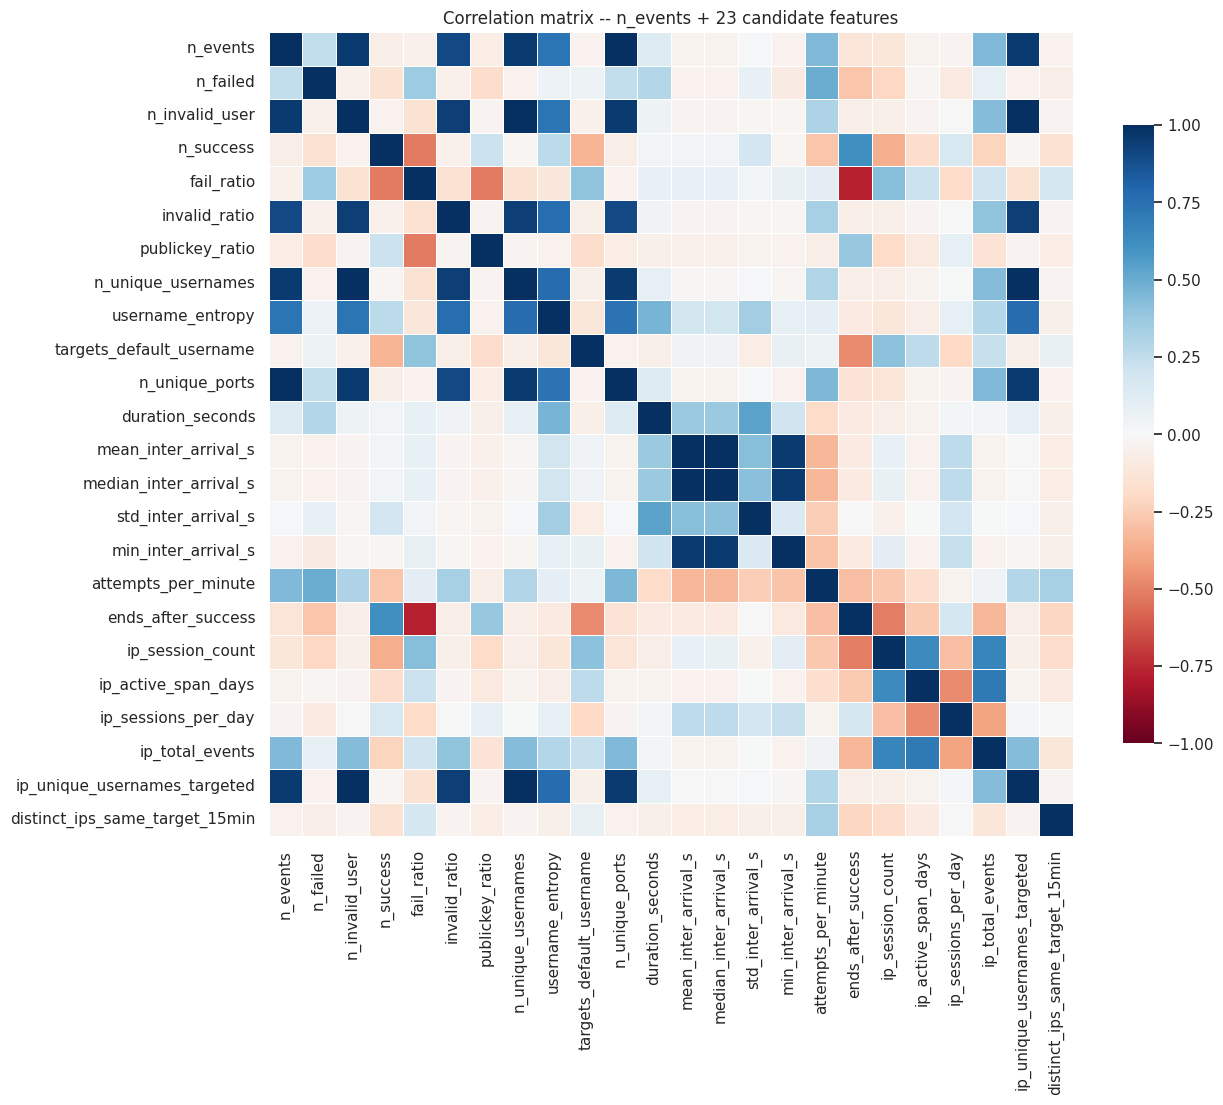

None

In [4]:
ALL_CANDIDATES = [
    "n_failed", "n_invalid_user", "n_success",
    "fail_ratio", "invalid_ratio", "publickey_ratio",
    "n_unique_usernames", "username_entropy", "targets_default_username",
    "n_unique_ports", "duration_seconds",
    "mean_inter_arrival_s", "median_inter_arrival_s", "std_inter_arrival_s", "min_inter_arrival_s",
    "attempts_per_minute", "ends_after_success",
    "ip_session_count", "ip_active_span_days", "ip_sessions_per_day",
    "ip_total_events", "ip_unique_usernames_targeted",
    "distinct_ips_same_target_15min",
]  # the same 23 candidates verify_features_v3.py checks -- n_events is left out of
   # this list (and out of the VIF/MI checks below) because the sanity check already
   # proved it is an exact duplicate of n_failed + n_invalid_user + n_success; it is
   # still plotted in the heatmap itself so that identity is visible directly

corr_cols = ["n_events"] + ALL_CANDIDATES
corr = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, linecolor="white", cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation matrix -- n_events + 23 candidate features")
plt.tight_layout()
plt.show()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print("Pairs with |correlation| > 0.85:")
print(high_corr[high_corr.abs() > 0.85])

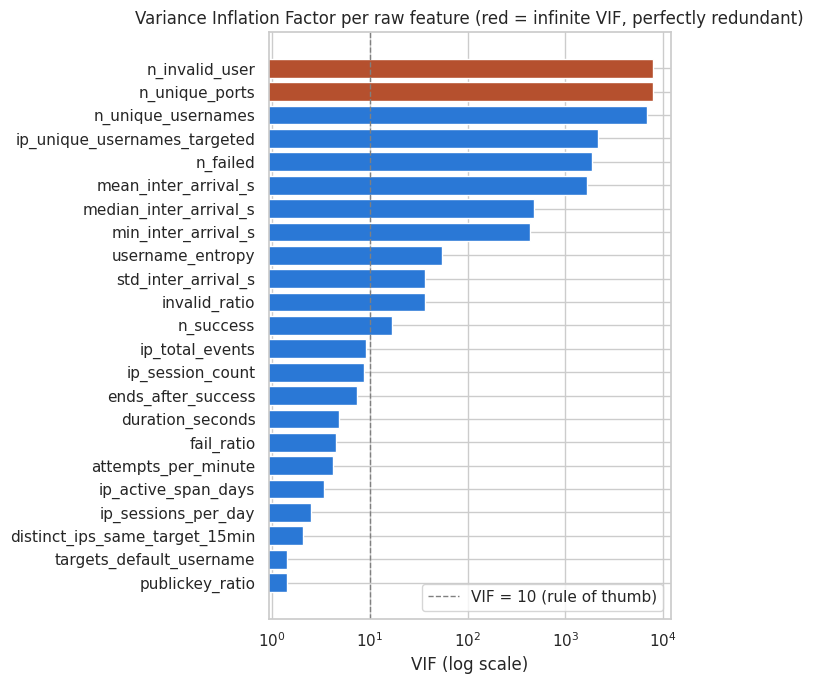

n_invalid_user                            inf
n_unique_ports                            inf
n_unique_usernames                6834.969682
ip_unique_usernames_targeted      2154.151630
n_failed                          1871.377523
mean_inter_arrival_s              1656.558563
median_inter_arrival_s             477.905269
min_inter_arrival_s                439.035723
username_entropy                    54.840700
std_inter_arrival_s                 36.678310
invalid_ratio                       36.358741
n_success                           17.040638
ip_total_events                      9.199790
ip_session_count                     8.756156
ends_after_success                   7.456245
duration_seconds                     4.828611
fail_ratio                           4.527360
attempts_per_minute                  4.152223
ip_active_span_days                  3.362967
ip_sessions_per_day                  2.513692
distinct_ips_same_target_15min       2.082538
targets_default_username          

In [5]:
def compute_vif(df, cols):
    X = df[cols].fillna(0).values
    X = np.column_stack([X, np.ones(len(X))])  # intercept
    vifs = {}
    for i, col in enumerate(cols):
        y_i = X[:, i]
        X_others = np.delete(X, i, axis=1)
        coef, *_ = np.linalg.lstsq(X_others, y_i, rcond=None)
        pred = X_others @ coef
        ss_res = np.sum((y_i - pred) ** 2)
        ss_tot = np.sum((y_i - y_i.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
        vifs[col] = 1 / (1 - r2) if r2 < 0.9999 else np.inf  # same threshold verify_features_v3.py uses
    return pd.Series(vifs).sort_values(ascending=False)

vif = compute_vif(features, ALL_CANDIDATES)

fig, ax = plt.subplots(figsize=(7, 7))
finite = vif.replace(np.inf, np.nan)
plot_vals = finite.fillna(finite.max() * 1.15)
colors = ["#b5502e" if np.isinf(v) else "#2a78d6" for v in vif]
ax.barh(vif.index[::-1], plot_vals[::-1], color=colors[::-1])
ax.set_xscale("log")
ax.set_xlabel("VIF (log scale)")
ax.set_title("Variance Inflation Factor per raw feature (red = infinite VIF, perfectly redundant)")
ax.axvline(10, color="gray", linestyle="--", linewidth=1, label="VIF = 10 (rule of thumb)")
ax.legend()
plt.tight_layout()
plt.show()
vif

**Mutual information** -- signal per feature in isolation, ignoring the redundancy correlation/VIF already captured above.

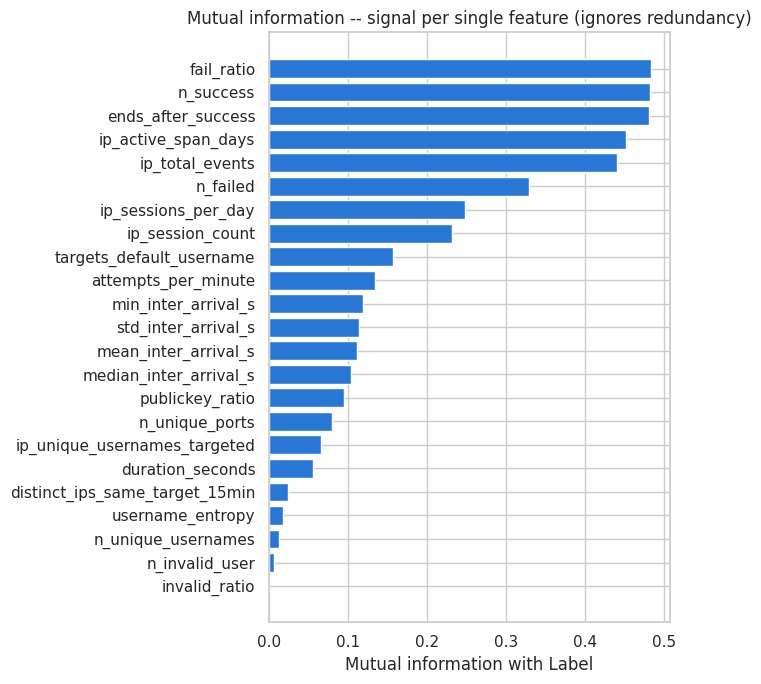

fail_ratio                        0.483823
n_success                         0.482095
ends_after_success                0.481025
ip_active_span_days               0.451341
ip_total_events                   0.440876
n_failed                          0.329149
ip_sessions_per_day               0.248137
ip_session_count                  0.231478
targets_default_username          0.156996
attempts_per_minute               0.134610
min_inter_arrival_s               0.119381
std_inter_arrival_s               0.114215
mean_inter_arrival_s              0.111229
median_inter_arrival_s            0.104412
publickey_ratio                   0.094975
n_unique_ports                    0.079886
ip_unique_usernames_targeted      0.066897
duration_seconds                  0.056396
distinct_ips_same_target_15min    0.023962
username_entropy                  0.018445
n_unique_usernames                0.013144
n_invalid_user                    0.007356
invalid_ratio                     0.000000
dtype: floa

In [6]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(
    mutual_info_classif(features[ALL_CANDIDATES].fillna(0), features["Label"], random_state=RANDOM_STATE),
    index=ALL_CANDIDATES,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(mi.index[::-1], mi.values[::-1], color="#2a78d6")
ax.set_xlabel("Mutual information with Label")
ax.set_title("Mutual information -- signal per single feature (ignores redundancy)")
plt.tight_layout()
plt.show()
mi

In [7]:
DROPPED_REDUNDANT = [
    "n_events", "n_invalid_user", "username_entropy", "n_unique_ports",
    "ip_unique_usernames_targeted", "mean_inter_arrival_s", "median_inter_arrival_s", "min_inter_arrival_s",
]
FEATURE_COLS = [
    "fail_ratio", "n_failed", "n_success", "invalid_ratio", "publickey_ratio",
    "n_unique_usernames", "targets_default_username", "ends_after_success",
    "duration_seconds", "std_inter_arrival_s", "attempts_per_minute",
    "ip_session_count", "ip_active_span_days", "ip_sessions_per_day", "ip_total_events",
    "distinct_ips_same_target_15min",
]
print(len(FEATURE_COLS), "features kept,", len(DROPPED_REDUNDANT), "dropped as redundant")
assert set(FEATURE_COLS).isdisjoint(DROPPED_REDUNDANT)


16 features kept, 8 dropped as redundant


### 2.1 Sanity check for the new time-window feature, by Attack_Type

Confirms `distinct_ips_same_target_15min` really is near-perfectly isolated to `coordinated_botnet_spike` before we rely on the claim above.

In [8]:
features.groupby("Attack_Type")["distinct_ips_same_target_15min"].agg(["median", "max"]).sort_values("median")

,median,max
Attack_Type,,
ambiguous_attack,0.0,1
ambiguous_legit,0.0,1
burst_bruteforce,0.0,1
credential_stuffing,0.0,2
large_dictionary_scanner,0.0,0
focused_bruteforce,0.0,1
legit_multi_ip_roaming,0.0,3
legit_success,0.0,2
persistent_multiday_attacker,0.0,2


### 2.2 Sanity check for IP-level persistence features, by Attack_Type

Confirms `persistent_multiday_attacker` and `low_and_slow` are the two patterns that actually need cross-session IP aggregation (their per-session stats alone are small).

In [9]:
features.groupby("Attack_Type")[["ip_session_count", "ip_active_span_days", "n_events"]].median().sort_values("ip_session_count")

,ip_session_count,ip_active_span_days,n_events
Attack_Type,,,
ambiguous_attack,1.0,0.000623,5.0
ambiguous_legit,1.0,0.002538,12.0
burst_bruteforce,1.0,0.000540,29.0
coordinated_botnet_spike,1.0,0.000095,4.0
credential_stuffing,1.0,0.004999,17.0
focused_bruteforce,1.0,0.004731,24.0
large_dictionary_scanner,1.0,0.004376,370.5
legit_multi_ip_roaming,1.0,0.000000,1.0
legit_success,1.0,0.000000,1.0


## 3. Train / test split

Stratified on `Attack_Type` so every pattern — including the small new classes — appears in both.

In [10]:
X = features[FEATURE_COLS]
y = features["Label"]
attack_type = features["Attack_Type"]

X_train, X_test, y_train, y_test, at_train, at_test = train_test_split(
    X, y, attack_type, test_size=0.25, random_state=RANDOM_STATE, stratify=attack_type,
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTest Attack_Type counts:\n", at_test.value_counts())


Train: (2934, 16)  Test: (979, 16)

Test Attack_Type counts:
 Attack_Type
low_and_slow                    270
legit_success                   155
legit_typo                      120
burst_bruteforce                110
persistent_multiday_attacker     87
coordinated_botnet_spike         72
legit_multi_ip_roaming           41
password_spray                   27
shared_ip_legit                  27
ambiguous_legit                  18
focused_bruteforce               18
ambiguous_attack                 16
credential_stuffing              11
large_dictionary_scanner          7
Name: count, dtype: int64


## 4. Models

Same three as v2 (Logistic Regression baseline, Random Forest, XGBoost), same class-balancing, 5-fold stratified CV scored on PR-AUC (average precision).

In [11]:
models = {
    "logreg": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision")
    cv_results[name] = scores
    print(f"{name:15s} PR-AUC: {scores.mean():.4f} +/- {scores.std():.4f}")


logreg          PR-AUC: 0.9961 +/- 0.0013


random_forest   PR-AUC: 0.9976 +/- 0.0008


xgboost         PR-AUC: 0.9979 +/- 0.0007


In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
print("All models fit on the training set.")


All models fit on the training set.


## 5. Evaluation on the held-out test set

In [13]:
results_summary = []
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=["legit", "attack"]))
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    f1 = f1_score(y_test, pred)
    print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}\n")
    results_summary.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1})

results_summary = pd.DataFrame(results_summary).set_index("model")
results_summary


=== logreg ===
              precision    recall  f1-score   support

       legit       0.94      1.00      0.97       361
      attack       1.00      0.96      0.98       618

    accuracy                           0.98       979
   macro avg       0.97      0.98      0.98       979
weighted avg       0.98      0.98      0.98       979

ROC-AUC: 0.9933   PR-AUC: 0.9966



=== random_forest ===
              precision    recall  f1-score   support

       legit       0.95      0.99      0.97       361
      attack       1.00      0.97      0.98       618

    accuracy                           0.98       979
   macro avg       0.97      0.98      0.98       979
weighted avg       0.98      0.98      0.98       979

ROC-AUC: 0.9940   PR-AUC: 0.9968

=== xgboost ===
              precision    recall  f1-score   support

       legit       0.95      0.98      0.97       361
      attack       0.99      0.97      0.98       618

    accuracy                           0.98       979
   macro avg       0.97      0.98      0.97       979
weighted avg       0.98      0.98      0.98       979

ROC-AUC: 0.9945   PR-AUC: 0.9971



,roc_auc,pr_auc,f1
model,,,
logreg,0.993326,0.996611,0.981878
random_forest,0.993976,0.996765,0.981967
xgboost,0.994451,0.997140,0.980424


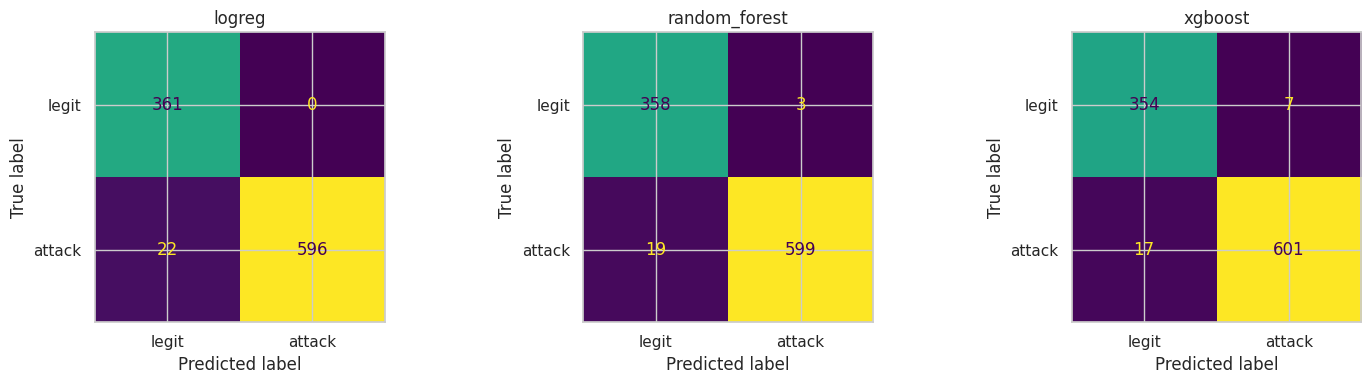

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["legit", "attack"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


### 5.1 Per-attack-type breakdown on the test set

The metric that matters most: does the model actually work on *every* behavior, not just in aggregate?

In [15]:
def per_type_breakdown(y_true, y_pred, proba, attack_types, name):
    rows = []
    for atype in attack_types.unique():
        mask = attack_types == atype
        n = mask.sum()
        lbl = y_true[mask].iloc[0] if hasattr(y_true, 'iloc') else y_true[mask][0]
        if lbl == 1:
            metric_name, value = "recall", (y_pred[mask] == 1).mean()
        else:
            metric_name, value = "false_positive_rate", (y_pred[mask] == 1).mean()
        rows.append({"model": name, "attack_type": atype, "n": n, "metric": metric_name, "value": value})
    return rows

breakdown = []
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    breakdown += per_type_breakdown(y_test.reset_index(drop=True), pred,
                                     proba, at_test.reset_index(drop=True), name)

breakdown_df = pd.DataFrame(breakdown).pivot_table(index=["attack_type", "n", "metric"], columns="model", values="value")
breakdown_df


,,model,logreg,random_forest,xgboost
attack_type,n,metric,,,
ambiguous_attack,16,recall,0.000000,0.000000,0.062500
ambiguous_legit,18,false_positive_rate,0.000000,0.166667,0.166667
burst_bruteforce,110,recall,1.000000,1.000000,1.000000
coordinated_botnet_spike,72,recall,1.000000,1.000000,1.000000
credential_stuffing,11,recall,1.000000,1.000000,1.000000
focused_bruteforce,18,recall,0.833333,0.833333,0.888889
large_dictionary_scanner,7,recall,1.000000,1.000000,1.000000
legit_multi_ip_roaming,41,false_positive_rate,0.000000,0.000000,0.000000
legit_success,155,false_positive_rate,0.000000,0.000000,0.000000


## 6. Out-of-distribution generalization check

`ssh_dataset_v3_ood.csv`: different random seed (777 vs 42), different scale (0.85x pattern counts), and a longer day span (45 vs 30 days) — generated once, never touched until now.

In [16]:
X_ood = features_ood[FEATURE_COLS]
y_ood = features_ood["Label"]
at_ood = features_ood["Attack_Type"]

ood_summary = []
for name, model in models.items():
    proba = model.predict_proba(X_ood)[:, 1]
    pred = model.predict(X_ood)
    roc_auc = roc_auc_score(y_ood, proba)
    pr_auc = average_precision_score(y_ood, proba)
    f1 = f1_score(y_ood, pred)
    ood_summary.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1})
ood_summary = pd.DataFrame(ood_summary).set_index("model")

print("Held-out TEST (same distribution as training):")
display(results_summary)
print("\nOOD set (different seed + shifted scale/day-span):")
display(ood_summary)
print("\nDrop (test - OOD):")
display(results_summary - ood_summary)


Held-out TEST (same distribution as training):


,roc_auc,pr_auc,f1
model,,,
logreg,0.993326,0.996611,0.981878
random_forest,0.993976,0.996765,0.981967
xgboost,0.994451,0.997140,0.980424



OOD set (different seed + shifted scale/day-span):


,roc_auc,pr_auc,f1
model,,,
logreg,0.992468,0.996229,0.981580
random_forest,0.993662,0.996660,0.982854
xgboost,0.993802,0.996993,0.981205



Drop (test - OOD):


,roc_auc,pr_auc,f1
model,,,
logreg,0.000858,0.000382,0.000298
random_forest,0.000314,0.000105,-0.000887
xgboost,0.000649,0.000147,-0.000781


In [17]:
ood_breakdown = []
for name, model in models.items():
    pred = model.predict(X_ood)
    ood_breakdown += per_type_breakdown(y_ood.reset_index(drop=True), pred,
                                         model.predict_proba(X_ood)[:, 1],
                                         at_ood.reset_index(drop=True), name)
pd.DataFrame(ood_breakdown).pivot_table(index=["attack_type", "n", "metric"], columns="model", values="value")


,,model,logreg,random_forest,xgboost
attack_type,n,metric,,,
ambiguous_attack,55,recall,0.000000,0.000000,0.000000
ambiguous_legit,60,false_positive_rate,0.000000,0.050000,0.033333
burst_bruteforce,374,recall,1.000000,1.000000,1.000000
coordinated_botnet_spike,178,recall,1.000000,1.000000,1.000000
credential_stuffing,38,recall,0.947368,1.000000,1.000000
focused_bruteforce,60,recall,0.900000,0.900000,0.900000
large_dictionary_scanner,26,recall,1.000000,1.000000,1.000000
legit_multi_ip_roaming,140,false_positive_rate,0.000000,0.000000,0.000000
legit_success,527,false_positive_rate,0.000000,0.000000,0.000000


## 7. Feature importance (permutation-based, not impurity-based — see verify_features_v3.py for the full bootstrap-stability version)

Evaluating the actually-deployed model: random_forest


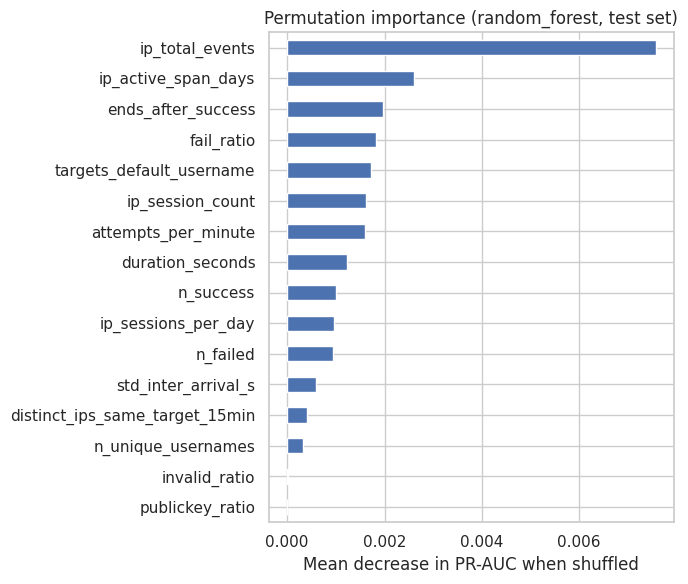

ip_total_events                   0.007570
ip_active_span_days               0.002609
ends_after_success                0.001972
fail_ratio                        0.001822
targets_default_username          0.001721
ip_session_count                  0.001615
attempts_per_minute               0.001594
duration_seconds                  0.001230
n_success                         0.000993
ip_sessions_per_day               0.000961
n_failed                          0.000936
std_inter_arrival_s               0.000593
distinct_ips_same_target_15min    0.000404
n_unique_usernames                0.000332
invalid_ratio                     0.000010
publickey_ratio                  -0.000004
dtype: float64

In [21]:
from sklearn.inspection import permutation_importance

# Evaluate the model that is actually shipped to production (backend/ and
# v3/ssh_bruteforce_model_v3.joblib) -- not the "random_forest" candidate trained
# above for the 3-way comparison, which used max_depth=None. Production locks in
# RandomForestClassifier(max_depth=8, ...) via retrain_rf.py regardless of which
# candidate happens to win the raw PR-AUC race above (xgboost edged it out by
# ~0.0003 in this run -- see results_summary; well within noise for this dataset).
deployed_bundle = joblib.load("ssh_bruteforce_model_v3.joblib")
best_model = deployed_bundle["model"]
best_name = deployed_bundle["model_name"]
print("Evaluating the actually-deployed model:", best_name)

pi = permutation_importance(best_model, X_test, y_test, n_repeats=20,
                             random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1)
importances = pd.Series(pi.importances_mean, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", figsize=(7, 6))
plt.title(f"Permutation importance ({best_name}, test set)")
plt.xlabel("Mean decrease in PR-AUC when shuffled")
plt.tight_layout()
plt.show()
importances.sort_values(ascending=False)


## 8. Threshold tuning

Same rationale as v2: in a SOC context a missed attack (false negative) usually costs more than a flagged legit session, so the default 0.5 cutoff is worth revisiting via the precision-recall curve.

Threshold for recall >= 0.95: 0.957 (precision at that point: 1.000)


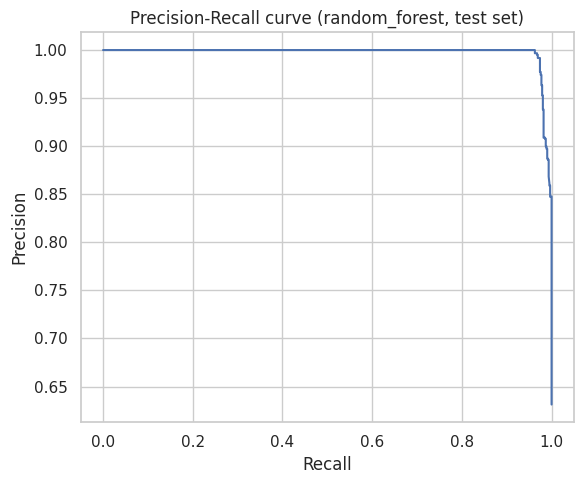

In [22]:
proba_best = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_best)

target_recall = 0.95
idx = np.where(recalls[:-1] >= target_recall)[0]
if len(idx):
    chosen_idx = idx[-1]
    chosen_threshold = thresholds[chosen_idx]
    chosen_precision = precisions[chosen_idx]
    print(f"Threshold for recall >= {target_recall}: {chosen_threshold:.3f} (precision at that point: {chosen_precision:.3f})")
else:
    print(f"No threshold in range reaches recall >= {target_recall} on this test set.")

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve ({best_name}, test set)")
plt.tight_layout()
plt.show()


## 9. Save the model artifact

In [23]:
joblib.dump(
    {"model": best_model, "feature_columns": FEATURE_COLS, "model_name": best_name,
     "dropped_redundant_features": DROPPED_REDUNDANT},
    "ssh_bruteforce_model_v3.joblib",
)
print(f"Saved: ssh_bruteforce_model_v3.joblib (best model: {best_name})")


Saved: ssh_bruteforce_model_v3.joblib (best model: random_forest)


## 10. Superseded by the multiclass model

The deployed model is no longer the binary Random Forest above. It is now **one multiclass Random Forest** (11 classes: 3 legit behaviours + 8 attack types) that gives both *Attack / Legit* and *which kind* in a single model.

See `train_multiclass_model.py` and `ssh_multiclass_pipeline.ipynb`. This notebook is kept as the record of how the 16 features were chosen and how the binary baseline performed.